## 1. Klasifikasi Flynn

### a. Operasi `arr + arr` pada NumPy array

Kategori: **SIMD (Single Instruction, Multiple Data)**

Alasannya, satu operasi yang sama dilakukan terhadap banyak elemen data pada array secara bersamaan. Jadi satu instruksi dapat memproses banyak data.

### b. Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris

Kategori: **SISD (Single Instruction, Single Data)**

Alasannya, program berjalan secara sekuensial dan memproses data satu per satu tanpa menggunakan proses atau thread secara paralel.

### c. Cluster komputer yang masing-masing node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen

Kategori: **MIMD (Multiple Instruction, Multiple Data)**

Alasannya, setiap node dapat menjalankan proses atau instruksi sendiri pada data yang berbeda secara independen.

## 2. Hukum Amdahl

Diketahui bagian program yang dapat diparalelkan adalah P = 0.85. Speedup dihitung menggunakan Hukum Amdahl dengan jumlah prosesor N = 2, 4, 8, 16, 32, dan 64.


In [9]:
def amdahl_speedup(P, N):
    return 1 / ((1 - P) + P / N)   

In [10]:
P = 0.85
N_values = [2, 4, 8, 16, 32, 64]

for N in N_values:
    speedup = amdahl_speedup(P, N)
    print(f"N = {N} -> Speedup = {speedup:.4f}")  

N = 2 -> Speedup = 1.7391
N = 4 -> Speedup = 2.7586
N = 8 -> Speedup = 3.9024
N = 16 -> Speedup = 4.9231
N = 32 -> Speedup = 5.6637
N = 64 -> Speedup = 6.1244


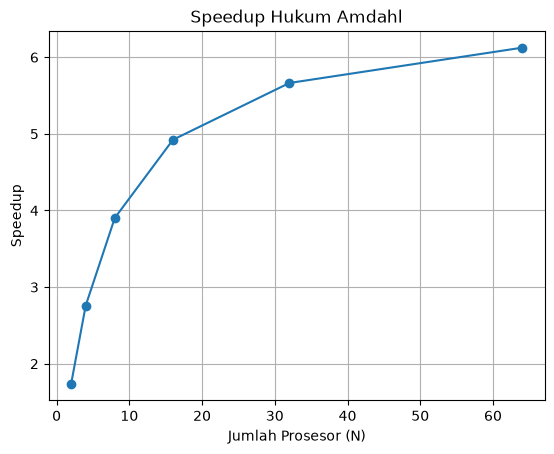

In [11]:
import matplotlib.pyplot as plt

speedups = [amdahl_speedup(P, N) for N in N_values]

plt.plot(N_values, speedups, marker='o')
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup")
plt.title("Speedup Hukum Amdahl")
plt.grid()
plt.show()

### Analisis Grafik

Dari grafik terlihat bahwa semakin banyak prosesor yang digunakan, speedup semakin meningkat. Namun, peningkatannya semakin kecil ketika jumlah prosesor bertambah. Hal ini terjadi karena masih ada bagian program yang tidak dapat diparalelkan, sehingga membatasi peningkatan speedup.

## 3. Benchmark Mandiri

Pada bagian ini digunakan fungsi Fibonacci rekursif sebagai contoh fungsi CPU-bound. Fungsi dijalankan dengan beberapa ukuran input yang berbeda, kemudian waktu eksekusinya diukur menggunakan `time.perf_counter()` dan `timeit`.

In [13]:
def fibonacci(n):
    if n <= 1:
        return n
    return fibonacci(n - 1) + fibonacci(n - 2)

In [14]:
print(fibonacci(10))

55


In [15]:
import time

N_values = [20, 25, 30, 35]

hasil_perf = []

for N in N_values:
    start = time.perf_counter()
    fibonacci(N)
    end = time.perf_counter()
    
    waktu = end - start
    hasil_perf.append(waktu)
    
    print(f"N = {N} -> Waktu = {waktu:.6f} detik")

N = 20 -> Waktu = 0.000690 detik
N = 25 -> Waktu = 0.009079 detik
N = 30 -> Waktu = 0.082808 detik
N = 35 -> Waktu = 0.814015 detik


In [16]:
import timeit

hasil_timeit = []

for N in N_values:
    waktu = timeit.timeit(lambda: fibonacci(N), number=1)
    hasil_timeit.append(waktu)
    
    print(f"N = {N} -> Waktu = {waktu:.6f} detik")

N = 20 -> Waktu = 0.000805 detik
N = 25 -> Waktu = 0.008916 detik
N = 30 -> Waktu = 0.086613 detik
N = 35 -> Waktu = 0.832883 detik


### Perbandingan Hasil Benchmark

| N | perf_counter (detik) | timeit (detik) |
|---:|---:|---:|
| 20 | 0.000690 | 0.000805 |
| 25 | 0.009079 | 0.008916 |
| 30 | 0.082808 | 0.086613 |
| 35 | 0.814015 | 0.832883 |

### Analisis

Dari hasil benchmark, waktu eksekusi meningkat cukup besar ketika nilai N bertambah. Hasil dari `perf_counter()` dan `timeit` juga memiliki nilai yang cukup dekat. Hal ini menunjukkan bahwa semakin besar input Fibonacci, semakin lama waktu yang dibutuhkan untuk menjalankannya.

## 4. Refleksi Singkat

Hukum Amdahl lebih relevan ketika ukuran masalah tetap dan kita ingin melihat batas peningkatan kinerja saat jumlah prosesor ditambah. Contohnya adalah menjalankan program dengan input yang sama menggunakan jumlah prosesor yang berbeda. Dari hasilnya, semakin banyak prosesor yang digunakan, speedup memang meningkat, tetapi peningkatannya semakin kecil karena masih ada bagian program yang tidak dapat diparalelkan. Jadi, penambahan prosesor tidak selalu membuat program menjadi jauh lebih cepat.

Sedangkan Hukum Gustafson lebih relevan ketika jumlah prosesor bertambah dan ukuran masalah juga dapat diperbesar. Contohnya adalah simulasi cuaca pada komputer paralel, di mana semakin banyak prosesor yang tersedia, semakin besar wilayah atau data yang bisa diproses. Menurut saya, Amdahl lebih cocok untuk melihat batas speedup pada masalah dengan ukuran tetap, sedangkan Gustafson lebih cocok untuk masalah yang skalanya ikut berkembang sesuai jumlah prosesor.

Dari percobaan ini, saya jadi lebih memahami bahwa penggunaan banyak prosesor tidak selalu menghasilkan peningkatan kinerja yang sebanding. Faktor seperti bagian program yang tidak bisa diparalelkan tetap memengaruhi hasil akhirnya.